In [76]:
# !pip install emoji

import re
import json
import emoji
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [52]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prakashpun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Get 100k data from the yelp_academic_dataset_review.json

In [53]:
input_file = "./yelp_dataset/yelp_academic_dataset_review.json"
output_file = "yelp_review.csv"
subset_size = 100000

chunk_size = 10000
processed_rows = 0
subset_data = []

for chunk in pd.read_json(input_file, lines=True, chunksize=chunk_size):
    chunk = chunk[['stars', 'text']]
    
    subset_data.append(chunk)
    processed_rows += len(chunk)
    
    # Stop if we have enough data
    if processed_rows >= subset_size:
        break


subset_df = pd.concat(subset_data[:subset_size], ignore_index=True)
subset_df.to_csv(output_file, index=False)
print(f"Saved {subset_size} reviews to {output_file}")

Saved 100000 reviews to yelp_review.csv


In [54]:
df = pd.read_csv("yelp_review.csv")

In [55]:
df.head()

,stars,text
0,3,"If you decide to eat here, just be aware it is..."
1,5,I've taken a lot of spin classes over the year...
2,3,Family diner. Had the buffet. Eclectic assortm...
3,5,"Wow! Yummy, different, delicious. Our favo..."
4,4,Cute interior and owner (?) gave us tour of up...


In [56]:
df.isnull().sum()

stars    0
text     0
dtype: int64

In [57]:
df.isna().sum()

stars    0
text     0
dtype: int64

In [58]:
df.describe()

,stars
count,100000.000000
mean,3.842910
std,1.354729
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [59]:
# Assuming df is your DataFrame containing the Yelp dataset
def map_stars_to_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Add a new column 'sentiment'
df['sentiment'] = df['stars'].apply(map_stars_to_sentiment)

In [60]:
df.head()

,stars,text,sentiment
0,3,"If you decide to eat here, just be aware it is...",Neutral
1,5,I've taken a lot of spin classes over the year...,Positive
2,3,Family diner. Had the buffet. Eclectic assortm...,Neutral
3,5,"Wow! Yummy, different, delicious. Our favo...",Positive
4,4,Cute interior and owner (?) gave us tour of up...,Positive


## Check Class Distribution

In [61]:
df['stars'].value_counts()

stars
5    44392
4    25337
3    11362
1    10921
2     7988
Name: count, dtype: int64

In [62]:
df['sentiment'].value_counts()

sentiment
Positive    69729
Negative    18909
Neutral     11362
Name: count, dtype: int64

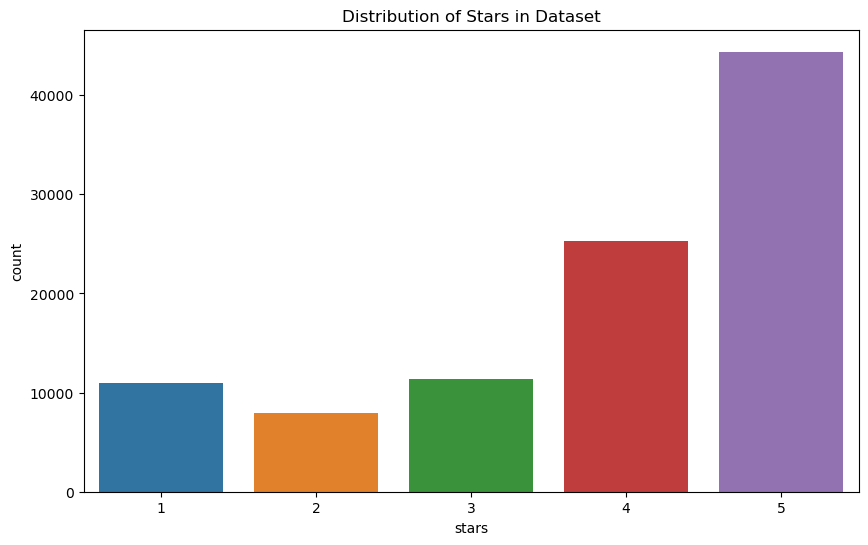

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(x='stars', data=df)
plt.title('Distribution of Stars in Dataset')
plt.show()

In [64]:
# Stratified Sampling (100k total, balanced across classes)
sample_size = 100000
classes = ['Positive', 'Neutral', 'Negative']
samples_per_class = sample_size // len(classes)

df_sampled = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), samples_per_class), random_state=42)
)

In [65]:
df_sampled.head()

,stars,text,sentiment
52533,2,I know that this place has been around forever...,Negative
52588,1,Why do I have to keep leaving updates? I spoke...,Negative
91257,1,I have never written a review before until now...,Negative
15635,1,"Asked for a trim and thinning out, got butcher...",Negative
36930,2,Been living in the area for 14yr. I'm used to ...,Negative


# Split Dataset

In [66]:
# Assuming `text` is the review column and `sentiment` is the target
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['sentiment'], test_size=0.2, stratify=df['sentiment'], random_state=42
)

In [67]:
X_train.head()

64688    Loved everything about these movers! From Jess...
95938    Came for breakfast with my husband. Everything...
32180    BYOB.  This is one of our favorite restaurants...
43933    Stopped by here for happy hour with some cowor...
30550    These guys made a usually horrific experience ...
Name: text, dtype: object

In [70]:
y_train.head()

64688    Positive
95938    Positive
32180    Positive
43933    Positive
30550    Positive
Name: sentiment, dtype: object

In [71]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Helper functions
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Handle hashtags (split camel case or connected words)
    text = re.sub(r'#([A-Za-z0-9]+)', lambda match: ' '.join(re.findall(r'[A-Z][^A-Z]*', match.group(1))), text)
    
    # Expand common abbreviations
    abbreviations = {
        "n't": "not",
        "'re": "are",
        "'s": "is",
        "'d": "would",
        "'ll": "will",
        "'ve": "have",
        "'m": "am",
        "lol": "laughing out loud",
        "brb": "be right back"
    }
    for abbr, full in abbreviations.items():
        text = re.sub(rf"{abbr}\b", full, text)
    
    # Replace idioms
    idioms = {
        "piece of cake": "easy",
        "break a leg": "good luck",
        "hit the nail on the head": "exactly right"
    }
    for idiom, meaning in idioms.items():
        text = text.replace(idiom, meaning)
    
    # Remove special characters and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    
    # Tokenize and lemmatize
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Join tokens back into a single string
    return ' '.join(tokens)

# Apply to dataset
# df['cleaned_text'] = df['text'].apply(clean_text)

In [72]:
X_train_cleaned = X_train.apply(clean_text)
X_test_cleaned = X_test.apply(clean_text)

In [74]:
X_train_cleaned.head()

64688    loved everything mover jessica phone vernon ma...
95938    came breakfast husband everything fresh delici...
32180    byob one favorite restaurant price reasonable ...
43933    stopped happy hour coworkers could stay short ...
30550    guy made usually horrific experience pleasant ...
Name: text, dtype: object

In [77]:
# Step 3: Feature Extraction (TF-IDF Vectorization)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit on training data and transform both train and test data
X_train_vectorized = vectorizer.fit_transform(X_train_cleaned)
X_test_vectorized = vectorizer.transform(X_test_cleaned)

# Step 4: Display Results
print("Cleaned Training Data:")
print(X_train_cleaned)

print("\nCleaned Test Data:")
print(X_test_cleaned)

print("\nTF-IDF Feature Names (first 10):")
print(vectorizer.get_feature_names_out()[:10])

print("\nShape of Vectorized Training Data:", X_train_vectorized.shape)
print("Shape of Vectorized Test Data:", X_test_vectorized.shape)

Cleaned Training Data:
64688    loved everything mover jessica phone vernon ma...
95938    came breakfast husband everything fresh delici...
32180    byob one favorite restaurant price reasonable ...
43933    stopped happy hour coworkers could stay short ...
30550    guy made usually horrific experience pleasant ...
                               ...                        
54579    sub tasty line move quick cool coke freestyle ...
41456    ihave gone multiple time consistently good foo...
87680    meal good located hotel priced accordingly bur...
66764    youwould think place called brodo youwould abl...
36555    excellent teff injera delicious dish kind serv...
Name: text, Length: 80000, dtype: object

Cleaned Test Data:
60902    ihg really stepped game indigo chain interesti...
12039    super nice staff pizza amazing strombolis good...
79026    absolutely favorite place wonderful staff grea...
92267    simply best mexican area lengua taco tinga tac...
95167    year travelling never 